Calculating Average.....
Congratulations Sujitha Passed
Average : 84.4
Calculating Average.....
Better luck next time Reshma
Average : 42.4


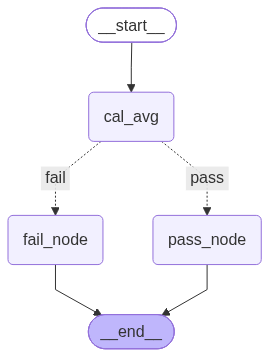

In [2]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class Stud_state(TypedDict):
    name : str
    marks : list
    avg : float
    status : str
    
def cal_avg(state : Stud_state):
    print("Calculating Average.....")
    return {
        "avg" : sum(state["marks"])/len(state["marks"])
    }
    
def pass_or_fail(state: Stud_state) -> Literal["pass","fail"]:
    if(state["avg"] >= 55):
        return "pass"
    else:
        return "fail"
    
def pass_node(state: Stud_state):
    print(f"Congratulations {state["name"]} Passed")
    print(f"Average : {state["avg"]}")
    return {
        "status" : "pass"
    }
        
def fail_node(state: Stud_state):
    print(f"Better luck next time {state["name"]}")
    print(f"Average : {state["avg"]}")
    return {
        "status" : "fail"
    }

builder = StateGraph(Stud_state)
builder.add_node("cal_avg",cal_avg)
builder.add_node("pass_node",pass_node)
builder.add_node("fail_node",fail_node)

builder.add_edge(START,"cal_avg")
builder.add_conditional_edges(
    "cal_avg",
    pass_or_fail,
    {
        "pass" : "pass_node",
        "fail" : "fail_node"
    }
    )
builder.add_edge("pass_node",END)
builder.add_edge("fail_node",END)

graph = builder.compile()
result1 = graph.invoke({"name":"Sujitha","marks":[90,78,89,67,98],"avg" : 0,"status":""})
result2 = graph.invoke({"name":"Reshma","marks":[40,58,39,47,28],"avg" : 0,"status":""})

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)